In [197]:
import os
from utils import *

import pennylane as qml
from pennylane import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

SEED = 1

# Generating the dataset

We will generate a synthetic dataset, generated by solving the Lorentz system using the Euler method. The Lorenz equations are defined as:

$$
\dot{x} = \sigma (y-x)
$$
$$
\dot{y} = -y -zx + \rho x
$$
$$
\dot{z} = -\beta z +xy
$$

where $(x, y, z)$ are the variables and $(\sigma , \rho , \beta)$ are parameters. 

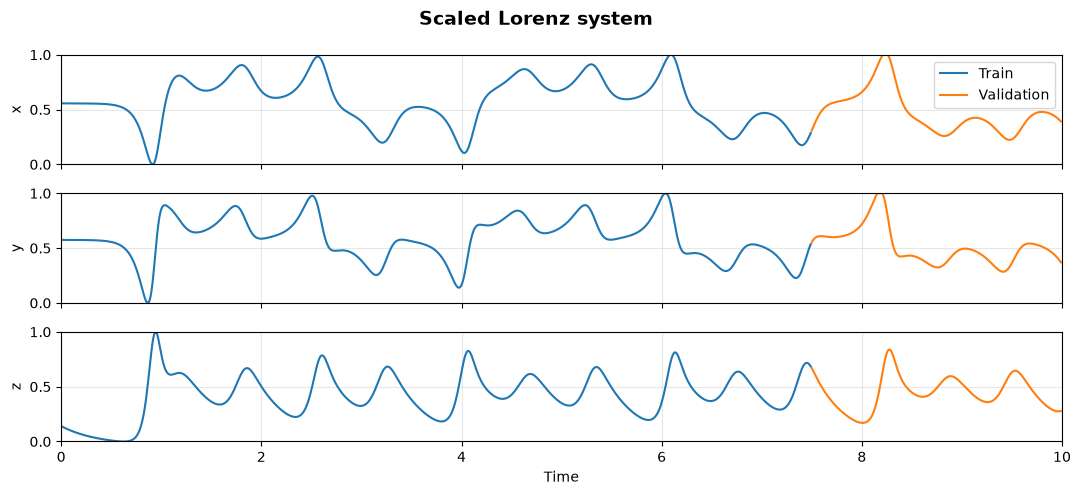

In [198]:
npoints = 1000
h = 0.01
params = [10, 28, 8 / 3]
init_point = [0, -0.01, 9]

dataset = generate_lorenz(
    npoints, 
    h,
    params, 
    init_point
)

# Trin test split
dataset_train, dataset_val = train_test_split(
    dataset,
    test_size=0.25,
    shuffle=False
)
time = np.arange(npoints) * h

time_tr = time[:len(dataset_train)]
time_val = time[len(dataset_train):]

# Scale the data to the range [0, 1]
scaler = MinMaxScaler()
train_scaled = scaler.fit_transform(dataset_train)
val_scaled = scaler.transform(dataset_val)
val_scaled = np.clip(val_scaled, 0, 1)

plot_lorenz(train_scaled, val_scaled, time_tr, time_val)

# Classical 1D CNN

In this section, we use a classical approach for benchmarking purposes. The chosen architecture consists of:

- Conv1D(1 → 8, stride=1, kernel=3, padding)
- Conv1D(8 → 8, stride=1, kernel=3, padding)
- ReLU
- MaxPool1D(kernel=3)
- Flatten
- Linear(8 → 16)
- ReLU
- Linear(16 → 3)

In [199]:
# Params
n_chanels = 3
window_size = 1
batch_size = 128

# Training hyperparameters
epochs = 50
lr = 5e-4

In [200]:
class Classic_CNN_Model(nn.Module):
    def __init__(self, horizon):
        super().__init__()

        self.conv1 = nn.Conv1d(
            in_channels=1,
            out_channels=8,
            kernel_size=3,
            stride=1,
            padding=1
        )
        self.conv2 = nn.Conv1d(
            in_channels=8,
            out_channels=8,
            kernel_size=3,
            stride=1,
            padding=1
        )
        self.relu = nn.ReLU()
        self.maxpool1d = nn.MaxPool1d(kernel_size=3)
        self.linear1 = nn.Linear(8, 16)
        self.linear2 = nn.Linear(16, 3*horizon)

    def forward(self, x):
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.relu(x)
        x = self.maxpool1d(x)
        x = x.flatten(start_dim=1)
        x = self.linear1(x)
        x = self.relu(x)
        x = self.linear2(x)
        return x

# Short forecasting

In [201]:
# Create the sequences
horizon_short = 1

x_tr_short, hor_tr_short = create_sequences(train_scaled, window_size, horizon_short)
x_val_short, hor_val_short = create_sequences(val_scaled, window_size, horizon_short)

x_tr_short = torch.from_numpy(x_tr_short).double()
hor_tr_short = torch.from_numpy(hor_tr_short).double()

x_val_short = torch.from_numpy(x_val_short).double()
hor_val_short = torch.from_numpy(hor_val_short).double()

tr_dataset_short = TensorDataset(x_tr_short, hor_tr_short)
tr_loader_short = DataLoader(tr_dataset_short, batch_size=batch_size, shuffle=False)

In [202]:
reset_seeds(SEED)

# Create the model
model_classic_CNN_short = Classic_CNN_Model(horizon_short).double()

# Define optimizer and loss function
opt_short = torch.optim.Adam(params=model_classic_CNN_short.parameters(), lr=lr)
loss_fn = nn.MSELoss()

# Save the best model
best_state_short = None
best_val_loss_short = float("inf")

history_short = {"Loss": [], "Val loss": []}

print(30 * "#")
print("Starting training")
print(30 * "#")

for epoch in range(epochs):

    #Training
    model_classic_CNN_short.train()
    epoch_loss = 0
    for xb, yb in tr_loader_short:
        opt_short.zero_grad()
        pred = model_classic_CNN_short(xb)
        target = yb.reshape(yb.shape[0], -1)
        loss = loss_fn(pred, target)    
        loss.backward()
        opt_short.step()
        epoch_loss += loss.item()
    
    # Store average loss for this epoch
    epoch_loss /= len(tr_loader_short)
    history_short["Loss"].append(epoch_loss)

    # Evaluation
    model_classic_CNN_short.eval()
    with torch.no_grad():
        val_pred = model_classic_CNN_short(x_val_short)
        val_target = hor_val_short.reshape(hor_val_short.shape[0], -1)
        val_loss = loss_fn(val_pred, val_target).item()

    # Store val loss
    history_short["Val loss"].append(val_loss)

    # Save best model
    if val_loss < best_val_loss_short:
        best_val_loss_short = val_loss
        best_state_short = {
            name: params.detach().clone()
            for name, params in model_classic_CNN_short.state_dict().items()
        }

    # Print training progress every 5 epochs
    if epoch == 0 or (epoch + 1) % 5 == 0:
        print(f"Epoch: {epoch + 1} | Loss: {epoch_loss:.4f} | Validation loss: {val_loss:.4f}")


if best_state_short is not None:
    model_classic_CNN_short.load_state_dict(best_state_short)

##############################
Starting training
##############################
Epoch: 1 | Loss: 0.1905 | Validation loss: 0.1387
Epoch: 5 | Loss: 0.1283 | Validation loss: 0.0844
Epoch: 10 | Loss: 0.0628 | Validation loss: 0.0344
Epoch: 15 | Loss: 0.0392 | Validation loss: 0.0253
Epoch: 20 | Loss: 0.0361 | Validation loss: 0.0266
Epoch: 25 | Loss: 0.0349 | Validation loss: 0.0268
Epoch: 30 | Loss: 0.0341 | Validation loss: 0.0267
Epoch: 35 | Loss: 0.0335 | Validation loss: 0.0264
Epoch: 40 | Loss: 0.0328 | Validation loss: 0.0260
Epoch: 45 | Loss: 0.0321 | Validation loss: 0.0255
Epoch: 50 | Loss: 0.0315 | Validation loss: 0.0250


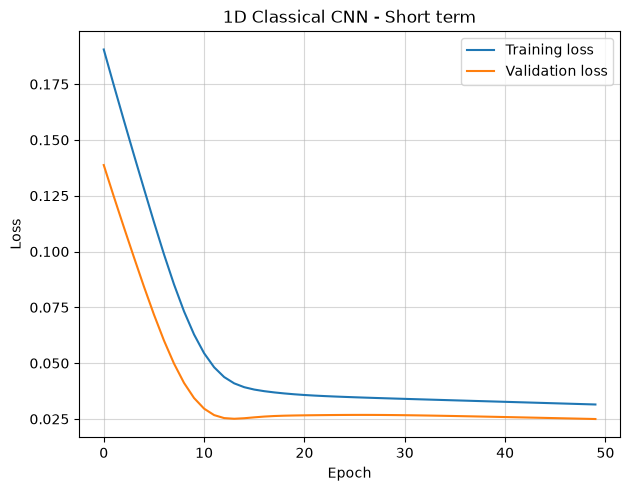

In [203]:
plot_loss(history_short, "1D Classical CNN - Short term")

In [204]:
# Evaluation mode
model_classic_CNN_short.eval()

with torch.no_grad():
    pred_short = model_classic_CNN_short(x_val_short)

pred_3d_short = pred_short.reshape(pred_short.shape[0], 1, 3)
target_3d_short = hor_val_short

# =====================
# RMSE
# =====================

squared_error_short = (pred_3d_short - target_3d_short) ** 2
mean_rmse_list_short = torch.sqrt(squared_error_short.mean(dim=(1, 2)))
mean_rmse_short = torch.sqrt(squared_error_short.mean())

# =====================
# MAE
# =====================

abs_error_short = torch.abs(pred_3d_short - target_3d_short)
mean_mae_list_short = abs_error_short.mean(dim=(1, 2))
mean_mae_short = abs_error_short.mean()

# =====================
# MAPE
# =====================

eps = 1e-8

percentage_error_short = torch.abs((target_3d_short - pred_3d_short) / (target_3d_short + eps))
mean_mape_list_short = percentage_error_short.mean(dim=(1, 2))
mean_mape_short = percentage_error_short.mean()

print(f"Global RMSE: {mean_rmse_short:.4f}")
print(f"Global MAE: {mean_mae_short:.4f}")
print(f"Global MAPE: {mean_mape_short:.4f}")

Global RMSE: 0.1580
Global MAE: 0.1322
Global MAPE: 0.3339


In [205]:
# Save the results to a CSV file
save_result_csv(
    "../results/lorenz_metrics.csv",
    {
        "forecasting": "short-term",
        "model": "1D Classical CNN",
        "MAPE": mean_mape_short,
        "MAE": mean_mae_short,
        "RMSE": mean_rmse_short,
    },
)

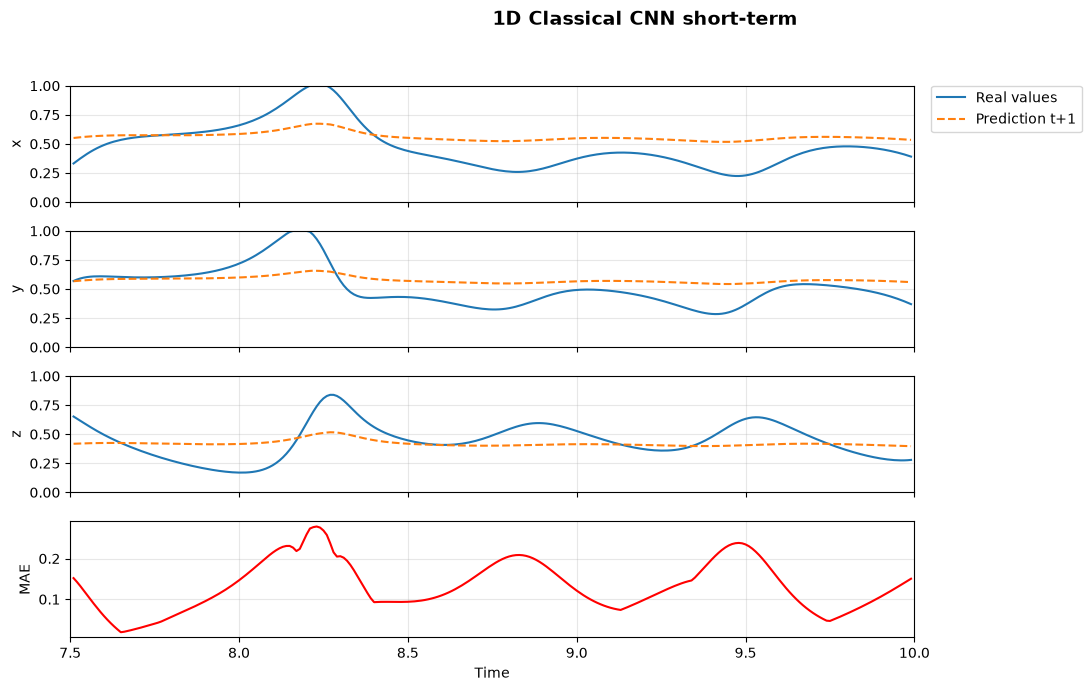

In [206]:
pred_x_short = pred_3d_short[:, :, 0]
pred_y_short = pred_3d_short[:, :, 1]
pred_z_short = pred_3d_short[:, :, 2]

plot_preds_and_error(
    pred_x_short,
    pred_y_short,
    pred_z_short,
    mean_mae_list_short,
    time_val,
    window_size,
    val_scaled,
    error="MAE",
    title="1D Classical CNN short-term"
)

# Long forecasting

In [207]:
# Create the sequences
horizon_long = 5

x_tr_long, hor_tr_long = create_sequences(train_scaled, window_size, horizon_long)
x_val_long, hor_val_long = create_sequences(val_scaled, window_size, horizon_long)

x_tr_long = torch.from_numpy(x_tr_long).double()
hor_tr_long = torch.from_numpy(hor_tr_long).double()

x_val_long = torch.from_numpy(x_val_long).double()
hor_val_long = torch.from_numpy(hor_val_long).double()

tr_dataset_long = TensorDataset(x_tr_long, hor_tr_long)
tr_loader_long = DataLoader(tr_dataset_long, batch_size=batch_size, shuffle=False)

In [208]:
reset_seeds(SEED)

# Create the model
model_classic_CNN_long = Classic_CNN_Model(horizon_long).double()

# Define optimizer and loss function
opt_long = torch.optim.Adam(params=model_classic_CNN_long.parameters(), lr=lr)
loss_fn = nn.MSELoss()

# Save the best model
best_state_long = None
best_val_loss_long = float("inf")

history_long = {"Loss": [], "Val loss": []}

print(30 * "#")
print("Starting training")
print(30 * "#")

for epoch in range(epochs):

    #Training
    model_classic_CNN_long.train()
    epoch_loss = 0
    for xb, yb in tr_loader_long:
        opt_long.zero_grad()
        pred = model_classic_CNN_long(xb)
        target = yb.reshape(yb.shape[0], -1)
        loss = loss_fn(pred, target)    
        loss.backward()
        opt_long.step()
        epoch_loss += loss.item()
    
    # Store average loss for this epoch
    epoch_loss /= len(tr_loader_long)
    history_long["Loss"].append(epoch_loss)

    # Evaluation
    model_classic_CNN_long.eval()
    with torch.no_grad():
        val_pred = model_classic_CNN_long(x_val_long)
        val_target = hor_val_long.reshape(hor_val_long.shape[0], -1)
        val_loss = loss_fn(val_pred, val_target).item()

    # Store val loss
    history_long["Val loss"].append(val_loss)

    # Save best model
    if val_loss < best_val_loss_long:
        best_val_loss_long = val_loss
        best_state_long = {
            name: params.detach().clone()
            for name, params in model_classic_CNN_long.state_dict().items()
        }

    # Print training progress every 5 epochs
    if epoch == 0 or (epoch + 1) % 5 == 0:
        print(f"Epoch: {epoch + 1} | Loss: {epoch_loss:.4f} | Validation loss: {val_loss:.4f}")


if best_state_long is not None:
    model_classic_CNN_long.load_state_dict(best_state_long)

##############################
Starting training
##############################
Epoch: 1 | Loss: 0.2082 | Validation loss: 0.1586
Epoch: 5 | Loss: 0.1755 | Validation loss: 0.1304
Epoch: 10 | Loss: 0.1294 | Validation loss: 0.0913
Epoch: 15 | Loss: 0.0841 | Validation loss: 0.0564
Epoch: 20 | Loss: 0.0536 | Validation loss: 0.0368
Epoch: 25 | Loss: 0.0406 | Validation loss: 0.0299
Epoch: 30 | Loss: 0.0358 | Validation loss: 0.0273
Epoch: 35 | Loss: 0.0338 | Validation loss: 0.0261
Epoch: 40 | Loss: 0.0326 | Validation loss: 0.0254
Epoch: 45 | Loss: 0.0318 | Validation loss: 0.0248
Epoch: 50 | Loss: 0.0310 | Validation loss: 0.0242


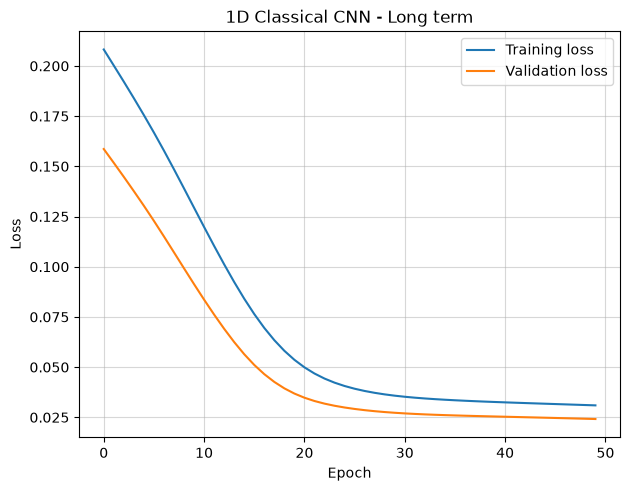

In [209]:
plot_loss(history_long, "1D Classical CNN - Long term")

In [210]:
# Evaluation mode
model_classic_CNN_long.eval()

with torch.no_grad():
    pred_long = model_classic_CNN_long(x_val_long)

pred_3d_long = pred_long.reshape(pred_long.shape[0], 5, 3)
target_3d_long = hor_val_long

# =====================
# RMSE
# =====================

squared_error_long = (pred_3d_long - target_3d_long) ** 2
mean_rmse_list_long = torch.sqrt(squared_error_long.mean(dim=(1, 2)))
mean_rmse_long = torch.sqrt(squared_error_long.mean())

# =====================
# MAE
# =====================

abs_error_long = torch.abs(pred_3d_long - target_3d_long)
mean_mae_list_long = abs_error_long.mean(dim=(1, 2))
mean_mae_long = abs_error_long.mean()

# =====================
# MAPE
# =====================

eps = 1e-8

percentage_error_long = torch.abs((target_3d_long - pred_3d_long) / (target_3d_long + eps))
mean_mape_list_long = percentage_error_long.mean(dim=(1, 2))
mean_mape_long = percentage_error_long.mean()


# =====================
# MAE in t+5 (for the plot)
# =====================

h = 4  # t+5

abs_error_t5 = torch.abs(pred_3d_long[:, h, :] - target_3d_long[:, h, :])
mean_mae_t5_list = abs_error_t5.mean(dim=1)

print(f"Global RMSE: {mean_rmse_long:.4f}")
print(f"Global MAE: {mean_mae_long:.4f}")
print(f"Global MAPE: {mean_mape_long:.4f}")

Global RMSE: 0.1554
Global MAE: 0.1293
Global MAPE: 0.3265


In [211]:
# Save the results to a CSV file
save_result_csv(
    "../results/lorenz_metrics.csv",
    {
        "forecasting": "long-term",
        "model": "1D Classical CNN",
        "MAPE": mean_mape_long,
        "MAE": mean_mae_long,
        "RMSE": mean_rmse_long,
    },
)

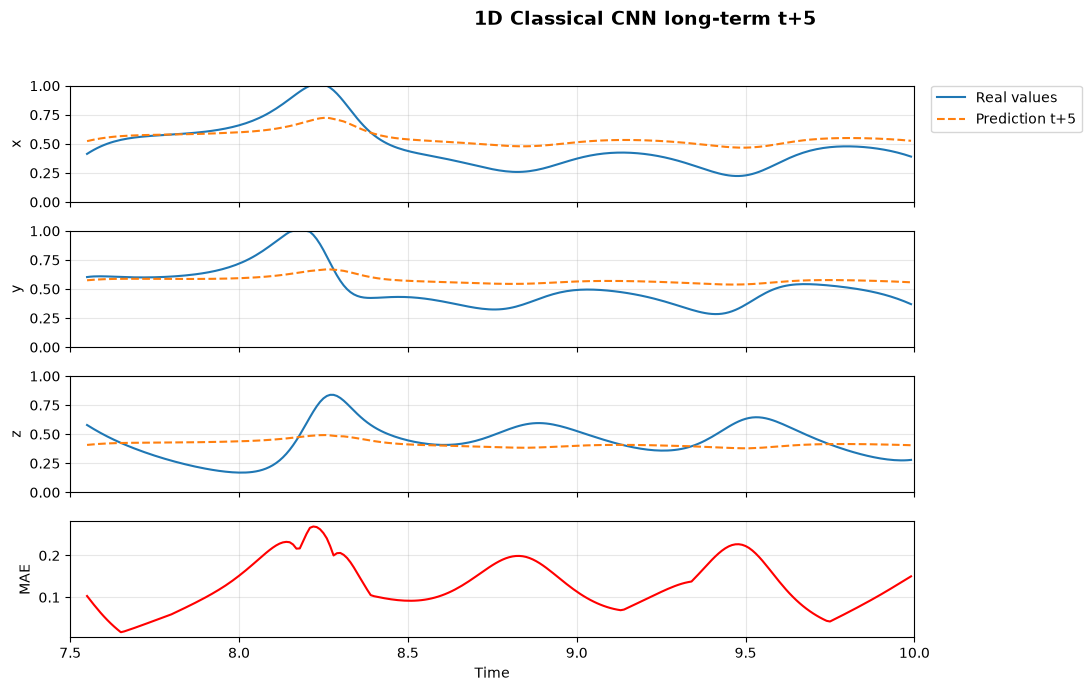

In [212]:
pred_x_long = pred_3d_long[:, :, 0]
pred_y_long = pred_3d_long[:, :, 1]
pred_z_long = pred_3d_long[:, :, 2]

plot_preds_and_error(
    pred_x_long,
    pred_y_long,
    pred_z_long,
    mean_mae_t5_list,
    time_val,
    window_size,
    val_scaled,
    error="MAE",
    horizon=horizon_long,
    horizon_step=5,
    title="1D Classical CNN long-term t+5"
)